In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

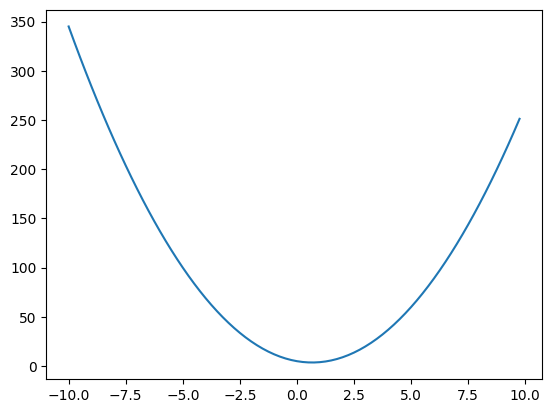

In [4]:
xs = np.arange(-10.0,10.0,0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.000000000001
x = 3.0
(f(x+h)-f(x))/h

14.001244608152774

In [ ]:
class Value:
    def __init__(self, data, _children = (), _op = None, label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        # suppose c = a + b
        # when c._backward is called, a and b's gradients are set according to the op and c's gradient
        # this is a function that defines the backward behaviour for differentiation at the local level basically
        # this has to be different for different functions
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value: {self.data}"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def back_of_out():
            self.grad += out.grad * 1.0 # because if out = a + b, d(L)/da = dL/da = dL/d(out) * d(out)/da = dL/d(out) * 1
            other.grad += out.grad * 1.0 # because if out = a + b, d(L)/da = dL/da = dL/d(out) * d(out)/da = dL/d(out) * 1
        
        out._backward = back_of_out
        return out 

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        
        def back_of_out():
            self.grad += out.grad * other.data  # accumulate: d(out)/d(self) = other.data, so dL/d(self) += dL/d(out) * other.data
            other.grad += out.grad * self.data  # accumulate: d(out)/d(other) = self.data, so dL/d(other) += dL/d(out) * self.data
        out._backward = back_of_out
        return out 
    
    def tnh(self):
        out = Value(np.tanh(self.data), (self,), 't')
        
        def back_of_out():
            self.grad += (1 - out.data**2) * out.grad  # accumulate: derivative of tanh is 1 - tanh^2, so dL/d(self) += dL/d(out) * (1 - tanh(self)^2)
        out._backward = back_of_out
        return out 
    
    def reset_grad(self):
        # reset gradients for the entire graph to avoid pollution from previous backward passes
        visited = set()
        def reset(node):    
            if node not in visited:
                visited.add(node)
                node.grad = 0.0
                for child in node._prev:
                    reset(child)
        reset(self)
    
    # we can add all nodes here as long as we know the derivative of that function

# in d = a*b + c, d is the root, 
# then a*b and c are the children
# further a, b are children of a*b

### This is how a neuron looks like

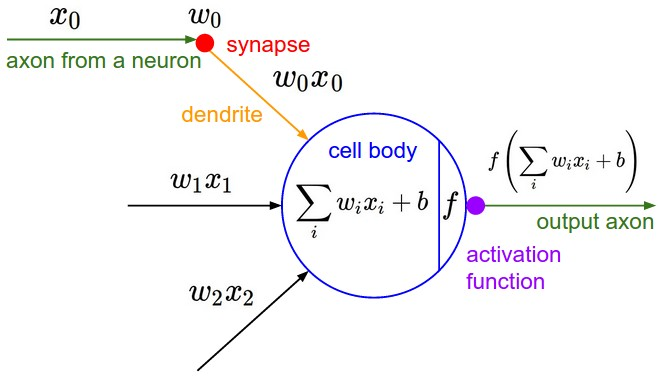

#### basically,
```
    -> x_1->n are the inputs,
    -> w_1->n are the weights 
        (which we want to nudge in the right direction by checking gradient and thinking in which direction does the overall loss function decrease)

    -> in our case f() is the tanh = normalising function,
    -> b is the bias which tells us the trigger happiness of the neuron 
```

In [26]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value: -8.0

In [8]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [10]:
L.grad = 1 

In [11]:
def dl_d(): # loss function something

    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0
              , label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data + h

    return (L2 - L1)/h

dl_d()

1.000000000000334

In [41]:
L.reset_grad()
L.grad = 1
L._backward()


In [45]:
# but we can call it in reverse topological sort order

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

# toposort of tree where all edges point upward is basically like postorder of tree 

build_topo(L)
topo

[Value: 10.0,
 Value: 2.0,
 Value: -3.0,
 Value: -6.0,
 Value: 4.0,
 Value: -2.0,
 Value: -8.0]

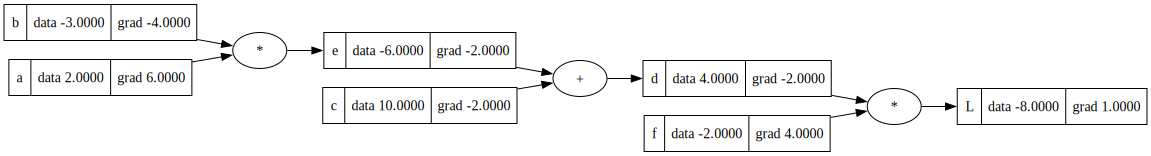

In [43]:
draw_dot(L)